In [3]:
from openflash import *
import numpy as np
import matplotlib.pyplot as plt
from openflash.multi_equations import wavenumber
import matplotlib.patches as mpatches

In [14]:
a_in_list = [0.3, 0.4]
d_in_list = [0.8, 0.7]
a_out_list = [0.6, 0.7]
d_out_list = [0.5, 0.4]
NMK=[10, 10, 10, 10, 10]
h = 1.0
omega = np.array([1.0])

bodyInnerFixed   = SteppedBody(a=np.array(a_in_list),  d=np.array(d_in_list),  slant_angle= np.zeros_like(a_in_list),  heaving=False)
bodyInnerHeaving = SteppedBody(a=np.array(a_in_list),  d=np.array(d_in_list),  slant_angle= np.zeros_like(a_in_list),  heaving=True)
bodyOuterFixed   = SteppedBody(a=np.array(a_out_list), d=np.array(d_out_list), slant_angle= np.zeros_like(a_out_list), heaving=False)
bodyOuterHeaving = SteppedBody(a=np.array(a_out_list), d=np.array(d_out_list), slant_angle= np.zeros_like(a_out_list), heaving=True)
arrangementHeavingOuter = ConcentricBodyGroup([bodyInnerFixed, bodyOuterHeaving])
arrangementHeavingInner = ConcentricBodyGroup([bodyInnerHeaving, bodyOuterFixed])
geometryHO = BasicRegionGeometry(body_arrangement=arrangementHeavingOuter, h=h, NMK=NMK)
geometryHI = BasicRegionGeometry(body_arrangement=arrangementHeavingInner, h=h, NMK=NMK)
problemHO = MEEMProblem(geometryHO)
problemHI = MEEMProblem(geometryHI)
problemHO.set_frequencies(omega)
problemHI.set_frequencies(omega)
probs = [problemHO, problemHI]
engine = MEEMEngine(problem_list=probs)
m0 = wavenumber(omega[0], h)

cache = engine.cache_list[problemHO]
engine._ensure_m_k_and_N_k_arrays(problemHO, m0)
A_HO = engine.assemble_A_multi(problemHO, m0)
b_HO = engine.assemble_b_multi(problemHO, m0) 

cache = engine.cache_list[problemHI]
engine._ensure_m_k_and_N_k_arrays(problemHI, m0)
A_HI = engine.assemble_A_multi(problemHI, m0)
b_HI = engine.assemble_b_multi(problemHI, m0) 

# c_on_outer = engine.assemble_c_vector(problemHO, [1,0])
# c_on_inner = engine.assemble_c_vector(problemHI, [1,0])
results_HO = engine.run_and_store_results(problem_index=0)
results_HI = engine.run_and_store_results(problem_index=1)
c_on_outer = results_HO.dataset['c_vector'].values
c_on_inner = results_HI.dataset['c_vector'].values


  ERROR: Solve failed for freq=1.0000, mode=1: ProblemCache.refresh_forcing_terms.<locals>.<lambda>() missing 1 required positional argument: 'Imk'
Hydrodynamic coefficients stored in xarray dataset.
  ERROR: Solve failed for freq=1.0000, mode=0: ProblemCache.refresh_forcing_terms.<locals>.<lambda>() missing 1 required positional argument: 'Imk'
Hydrodynamic coefficients stored in xarray dataset.


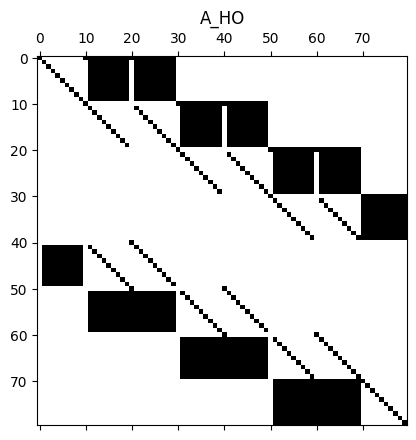

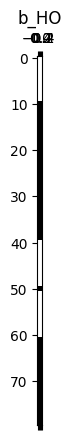

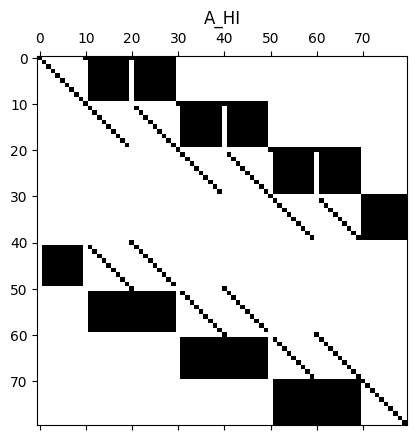

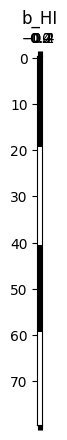

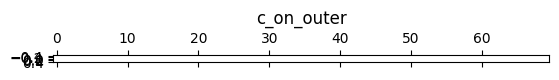

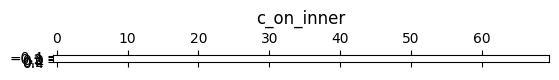

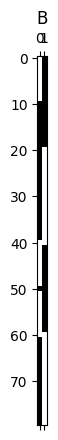

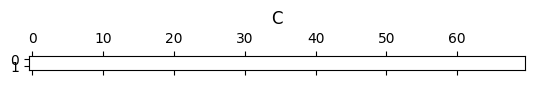

In [19]:
# original before moving rows/cols around
plt.spy(A_HO)
plt.title("A_HO")
plt.show()

plt.spy(b_HO[:,np.newaxis])
plt.title("b_HO")
plt.show()

plt.spy(A_HI)
plt.title("A_HI")
plt.show()

plt.spy(b_HI[:,np.newaxis])
plt.title("b_HI")
plt.show()

plt.spy(c_on_outer[0,:,:])
plt.title("c_on_outer")
plt.show()

plt.spy(c_on_inner[0,:,:])
plt.title("c_on_inner")
plt.show()

B = np.concatenate([b_HO[:,np.newaxis], b_HI[:,np.newaxis]],axis=1)
plt.spy(B)
plt.title("B")
plt.show()

C = np.concatenate([c_on_outer[0,:,:], c_on_inner[0,:,:]],axis=0)
plt.spy(C)
plt.title("C")
plt.show()

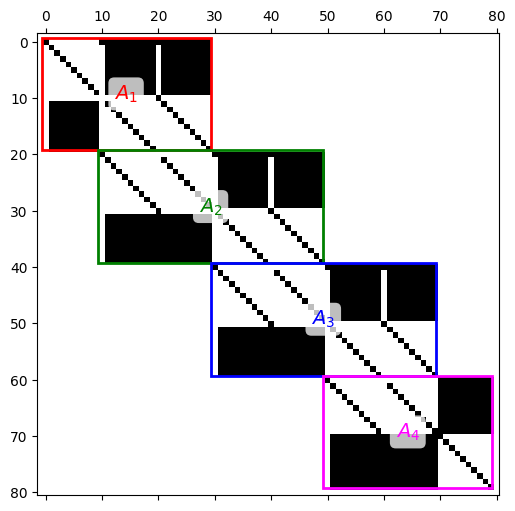

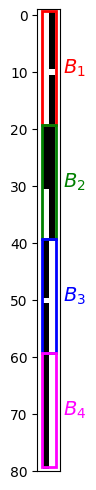

In [ ]:
A_new = np.zeros_like(A_HO)

# Build block sizes: first and last use NMK[0] and NMK[-1], middle entries are repeated twice
block_sizes = [NMK[0]] + [x for x in NMK[1:-1] for _ in (0,1)] + [NMK[-1]]
block_sizes = np.array(block_sizes)

num_blocks = len(block_sizes)

# Permutation expressed as the original block indices at each NEW position (0-based)
perm_new_positions = np.array([0,4,1,5,2,6,3,7])

# Starting indices for old blocks in the original matrix
old_starts = np.concatenate([[0], np.cumsum(block_sizes)[:-1]])
# Starting indices for new blocks in the reordered matrix (blocks appear in perm_new_positions order)
new_block_sizes = block_sizes[perm_new_positions]
new_starts = np.concatenate([[0], np.cumsum(new_block_sizes)[:-1]])

# Fill A_new by placing each old block into its new position
for new_br in range(num_blocks):
    old_br = perm_new_positions[new_br]
    old_r0 = old_starts[old_br]
    old_r1 = old_r0 + block_sizes[old_br]
    new_r0 = new_starts[new_br]
    new_r1 = new_r0 + block_sizes[old_br]
    for new_bc in range(num_blocks):
        old_bc = perm_new_positions[new_bc]
        old_c0 = old_starts[old_bc]
        old_c1 = old_c0 + block_sizes[old_bc]
        A_new[new_r0:new_r1, old_c0:old_c1] = A_HO[old_r0:old_r1, old_c0:old_c1]

# Reorder right-hand side (rows) the same way
B_new = np.zeros_like(B)
for new_br in range(num_blocks):
    old_br = perm_new_positions[new_br]
    old_r0 = old_starts[old_br]
    old_r1 = old_r0 + block_sizes[old_br]
    new_r0 = new_starts[new_br]
    new_r1 = new_r0 + block_sizes[old_br]
    B_new[new_r0:new_r1,:] = B[old_r0:old_r1,:]



# Plot reordered matrix and overlay rectangles around specified block groups
fig, ax = plt.subplots(figsize=(6,6))
ax.spy(A_new)

# Define rectangles as (col_indices, row_indices, color) using NEW block indices (0-based)
rects = [
    ([0,1,2], [0,1], 'red'),
    ([1,2,3,4], [2,3], 'green'),
    ([3,4,5,6], [4,5], 'blue'),
    ([5,6,7], [6,7], 'magenta'),
]

m=1
for cols, rows, color in rects:
    col0 = min(cols)
    row0 = min(rows)
    x = new_starts[col0]-.75
    y = new_starts[row0]-.75
    width  = new_block_sizes[cols].sum()
    height = new_block_sizes[rows].sum()
    rect = mpatches.Rectangle((x, y), width, height, fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)

    ax.text(x+width/2, y+height/2, f'$A_{m}$', color=color, ha='center', va='center', fontsize=14,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.75, edgecolor='none'))
    m += 1

plt.xlim(-1.5, A_new.shape[1]+.5)
plt.ylim(A_new.shape[0]+.5, -1.5)
plt.show()

fig2, ax = plt.subplots(figsize=(6,6))
ax.spy(B_new)

m=1
for rows, color in [([0,1], 'red'), ([2,3], 'green'), ([4,5], 'blue'), ([6,7], 'magenta')]:
    row0 = min(rows)
    y = new_starts[row0]-.75
    height = new_block_sizes[rows].sum()
    rect = mpatches.Rectangle((-.75, y), 2.5, height, fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(5, y+height/2, f'$B_{m}$', color=color, ha='center', va='center', fontsize=14)
    m += 1
plt.xlim(-1.5, 2.5)
plt.ylim(B_new.shape[0], -1)
plt.xticks([])
plt.show()

In [ ]:
fig.savefig('../pubs/JFM/figs/A_sparsity_plot.pdf', dpi=300,bbox_inches='tight', pad_inches=0)
fig2.savefig('../pubs/JFM/figs/B_sparsity_plot.pdf', dpi=300,bbox_inches='tight', pad_inches=0)